In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


In [2]:
from scipy.stats import mode
from sklearn import datasets, tree
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (roc_auc_score, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)

In [3]:


from imblearn.over_sampling import SMOTE
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
import pandas as pd

data =pd.read_csv("final_dataset_PART2.csv")

print(f'Dataset Shape: {data.shape}')
print(f' Dataset Memory Usage: {data.memory_usage().sum() / 1024 ** 2:.2f} MB')

Dataset Shape: (1480, 62)
 Dataset Memory Usage: 0.32 MB


In [6]:
print(f'Dataset Shape: {data.shape}')


Dataset Shape: (1480, 62)


In [7]:
data = data.drop('Cancer Type', axis=1)


### Analýza atribútov pomocou Coxovej regresie

##### Najprv som testovala každý atribút samostatne pomocou jednorozmernej Coxovej regresie. Cieľom bolo zistiť, či má daný atribút významný vplyv na prežitie pacientov. Pre každý atribút som vytvorila individuálny model a zaznamenala som jeho p-hodnotu a HR (Hazard Ratio).

In [8]:
cancer_type = data['event'].value_counts()
print(cancer_type)

event
0    835
1    645
Name: count, dtype: int64


In [9]:
from lifelines import CoxPHFitter

# Vytvorenie modelu pre 'Age at Diagnosis'
relevant_attributes = ['event', 'time', 'Age at Diagnosis']
age_at_diagnosis_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(age_at_diagnosis_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4354.75
         time fit was run = 2025-03-18 15:35:57 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
Age at Diagnosis  0.02      1.02      0.00            0.02            0.03                1.02                1.03

                  cmp to    z      p  -log2(p)
covariate                                     
Age at Diagnosis    0.00 6.79 <0.005     36.37
---
Concordance = 0.56
Partial AIC = 8711.50
log-likelihood ratio test = 46.74 on 1 df
-log2(p) of ll-ratio test = 36.84

In [10]:
# Vytvorenie modelu pre 'Type of Breast Surgery'
relevant_attributes = ['event', 'time', 'Type of Breast Surgery']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4353.54
         time fit was run = 2025-03-18 15:36:00 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
Type of Breast Surgery  0.58      1.78      0.08            0.41            0.74                1.51                2.10

                        cmp to    z      p  -log2(p)
covariate                                           
Type of Breast Surgery    0.00 6.81 <0.005     36.62
---
Concordance = 0.57
Partial AIC = 8709.08
log-likelihood ratio test = 49.16 on 1 df
-log2(p) of ll-ratio test = 38.63

In [11]:
relevant_attributes = ['event', 'time', 'Cellularity']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4377.89
         time fit was run = 2025-03-18 15:36:06 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
Cellularity  0.04      1.04      0.06           -0.08            0.16                0.93                1.17

             cmp to    z    p  -log2(p)
covariate                              
Cellularity    0.00 0.67 0.50      1.00
---
Concordance = 0.51
Partial AIC = 8757.78
log-likelihood ratio test = 0.46 on 1 df
-log2(p) of ll-ratio test = 1.00

In [12]:
relevant_attributes = ['event', 'time', 'Chemotherapy']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4362.02
         time fit was run = 2025-03-18 15:36:10 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
Chemotherapy  0.50      1.65      0.09            0.34            0.67                1.40                1.96

              cmp to    z      p  -log2(p)
covariate                                 
Chemotherapy    0.00 5.88 <0.005     27.82
---
Concordance = 0.57
Partial AIC = 8726.05
log-likelihood ratio test = 32.19 on 1 df
-log2(p) of ll-ratio test = 26.09

In [13]:
relevant_attributes = ['event', 'time', 'Cohort']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4376.60
         time fit was run = 2025-03-18 15:36:15 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Cohort     0.06      1.06      0.03           -0.01            0.12                0.99                1.13

           cmp to    z    p  -log2(p)
covariate                            
Cohort       0.00 1.75 0.08      3.64
---
Concordance = 0.52
Partial AIC = 8755.19
log-likelihood ratio test = 3.04 on 1 df
-log2(p) of ll-ratio test = 3.62

In [14]:
relevant_attributes = ['event', 'time', 'ER status measured by IHC']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4369.71
         time fit was run = 2025-03-18 15:36:18 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
ER status measured by IHC -0.37      0.69      0.09           -0.54           -0.20                0.58                0.82

                           cmp to     z      p  -log2(p)
covariate                                               
ER status measured by IHC    0.00 -4.21 <0.005     15.28
---
Concordance = 0.56
Partial AIC = 8741.43
log-likelihood ratio test = 16.81 on 1 df
-log2(p) of ll-ratio test = 14.56

In [15]:
relevant_attributes = ['event', 'time', 'ER Status']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4370.09
         time fit was run = 2025-03-18 15:36:20 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
ER Status -0.35      0.70      0.09           -0.52           -0.19                0.59                0.83

           cmp to     z      p  -log2(p)
covariate                               
ER Status    0.00 -4.11 <0.005     14.63
---
Concordance = 0.56
Partial AIC = 8742.17
log-likelihood ratio test = 16.06 on 1 df
-log2(p) of ll-ratio test = 13.99

In [16]:
relevant_attributes = ['event', 'time', 'Neoplasm Histologic Grade']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4351.54
         time fit was run = 2025-03-18 15:36:30 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
Neoplasm Histologic Grade  0.48      1.62      0.07            0.35            0.61                1.41                1.85

                           cmp to    z      p  -log2(p)
covariate                                              
Neoplasm Histologic Grade    0.00 6.99 <0.005     38.40
---
Concordance = 0.59
Partial AIC = 8705.09
log-likelihood ratio test = 53.15 on 1 df
-log2(p) of ll-ratio test = 41.56

In [17]:
relevant_attributes = ['event', 'time', 'HER2 Status']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4364.47
         time fit was run = 2025-03-18 15:36:36 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
HER2 Status  0.56      1.76      0.10            0.36            0.76                1.44                2.14

             cmp to    z      p  -log2(p)
covariate                                
HER2 Status    0.00 5.55 <0.005     25.04
---
Concordance = 0.54
Partial AIC = 8730.94
log-likelihood ratio test = 27.30 on 1 df
-log2(p) of ll-ratio test = 22.45

In [18]:
relevant_attributes = ['event', 'time', 'Hormone Therapy']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4377.58
         time fit was run = 2025-03-18 15:36:38 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
Hormone Therapy  0.08      1.09      0.08           -0.08            0.24                0.93                1.28

                 cmp to    z    p  -log2(p)
covariate                                  
Hormone Therapy    0.00 1.04 0.30      1.74
---
Concordance = 0.49
Partial AIC = 8757.16
log-likelihood ratio test = 1.08 on 1 df
-log2(p) of ll-ratio test = 1.74

In [19]:
relevant_attributes = ['event', 'time', 'Inferred Menopausal State']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4374.72
         time fit was run = 2025-03-18 15:36:40 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
Inferred Menopausal State  0.24      1.27      0.09            0.05            0.42                1.06                1.52

                           cmp to    z    p  -log2(p)
covariate                                            
Inferred Menopausal State    0.00 2.56 0.01      6.56
---
Concordance = 0.51
Partial AIC = 8751.45
log-likelihood ratio test = 6.79 on 1 df
-log2(p) of ll-ratio test = 6.77

In [20]:
relevant_attributes = ['event', 'time', 'Primary Tumor Laterality']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4376.66
         time fit was run = 2025-03-18 15:36:42 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
Primary Tumor Laterality  0.14      1.15      0.08           -0.02            0.29                0.98                1.34

                          cmp to    z    p  -log2(p)
covariate                                           
Primary Tumor Laterality    0.00 1.70 0.09      3.50
---
Concordance = 0.52
Partial AIC = 8755.32
log-likelihood ratio test = 2.92 on 1 df
-log2(p) of ll-ratio test = 3.51

In [21]:
relevant_attributes = ['event', 'time', 'Lymph nodes examined positive']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4327.58
         time fit was run = 2025-03-18 15:36:44 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
Lymph nodes examined positive  0.07      1.07      0.01            0.06            0.08                1.06                1.08

                               cmp to     z      p  -log2(p)
covariate                                                   
Lymph nodes examined positive    0.00 13.04 <0.005    126.61
---
Concordance = 0.63
Partial AIC = 8657.16
log-likelihood ratio test = 101.07 on 1 df
-log2(p) of ll-ratio test = 76.58

In [22]:
relevant_attributes = ['event', 'time', 'Mutation Count']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4377.18
         time fit was run = 2025-03-18 15:36:46 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Mutation Count  0.02      1.02      0.01           -0.01            0.04                0.99                1.04

                cmp to    z    p  -log2(p)
covariate                                 
Mutation Count    0.00 1.39 0.16      2.61
---
Concordance = 0.52
Partial AIC = 8756.36
log-likelihood ratio test = 1.88 on 1 df
-log2(p) of ll-ratio test = 2.55

In [23]:
relevant_attributes = ['event', 'time', 'Nottingham prognostic index']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4296.72
         time fit was run = 2025-03-18 15:36:48 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
Nottingham prognostic index  0.47      1.59      0.04            0.39            0.54                1.48                1.71

                             cmp to     z      p  -log2(p)
covariate                                                 
Nottingham prognostic index    0.00 12.57 <0.005    117.99
---
Concordance = 0.67
Partial AIC = 8595.45
log-likelihood ratio test = 162.79 on 1 df
-log2(p) of ll-ratio test = 121.44

In [24]:
relevant_attributes = ['event', 'time', 'PR Status']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4365.08
         time fit was run = 2025-03-18 15:36:49 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
PR Status -0.40      0.67      0.08           -0.56           -0.25                0.57                0.78

           cmp to     z      p  -log2(p)
covariate                               
PR Status    0.00 -5.09 <0.005     21.39
---
Concordance = 0.57
Partial AIC = 8732.17
log-likelihood ratio test = 26.07 on 1 df
-log2(p) of ll-ratio test = 21.53

In [25]:
relevant_attributes = ['event', 'time', 'Radio Therapy']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4377.45
         time fit was run = 2025-03-18 15:36:51 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
Radio Therapy -0.09      0.91      0.08           -0.25            0.06                0.78                1.07

               cmp to     z    p  -log2(p)
covariate                                 
Radio Therapy    0.00 -1.16 0.25      2.03
---
Concordance = 0.51
Partial AIC = 8756.90
log-likelihood ratio test = 1.34 on 1 df
-log2(p) of ll-ratio test = 2.02

In [26]:
relevant_attributes = ['event', 'time', 'Relapse Free Status (Months)']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -3742.31
         time fit was run = 2025-03-18 15:36:53 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
Relapse Free Status (Months) -0.03      0.98      0.00           -0.03           -0.02                0.97                0.98

                              cmp to      z      p  -log2(p)
covariate                                                   
Relapse Free Status (Months)    0.00 -28.80 <0.005    603.44
---
Concordance = 0.93
Partial AIC = 7486.62
log-likelihood ratio test = 1271.61 on 1 df
-log2(p) of ll-ratio test = 922.76

In [27]:
relevant_attributes = ['event', 'time', 'Relapse Free Status']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -3752.71
         time fit was run = 2025-03-18 15:36:55 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Relapse Free Status 20.57  8.54e+08    886.51        -1716.96         1758.09                0.00                 inf

                     cmp to    z    p  -log2(p)
covariate                                      
Relapse Free Status    0.00 0.02 0.98      0.03
---
Concordance = 0.80
Partial AIC = 7507.43
log-likelihood ratio test = 1250.81 on 1 df
-log2(p) of ll-ratio test = 907.74

In [28]:
relevant_attributes = ['event', 'time', 'Tumor Size']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4343.18
         time fit was run = 2025-03-18 15:36:57 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
Tumor Size  0.02      1.02      0.00            0.01            0.02                1.01                1.02

            cmp to     z      p  -log2(p)
covariate                                
Tumor Size    0.00 10.30 <0.005     80.16
---
Concordance = 0.63
Partial AIC = 8688.36
log-likelihood ratio test = 69.88 on 1 df
-log2(p) of ll-ratio test = 53.82

In [29]:
relevant_attributes = ['event', 'time', 'Tumor Stage']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4322.43
         time fit was run = 2025-03-18 15:37:00 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
Tumor Stage  0.72      2.06      0.07            0.59            0.85                1.81                2.35

             cmp to     z      p  -log2(p)
covariate                                 
Tumor Stage    0.00 10.76 <0.005     87.21
---
Concordance = 0.61
Partial AIC = 8646.87
log-likelihood ratio test = 111.37 on 1 df
-log2(p) of ll-ratio test = 84.07

In [30]:
relevant_attributes = ['event', 'time', 'Cancer_Type_Breast Invasive Ductal Carcinoma']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4376.64
         time fit was run = 2025-03-18 15:37:02 UTC

---
                                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                     
Cancer_Type_Breast Invasive Ductal Carcinoma  0.17      1.18      0.10           -0.03            0.36                0.97                1.44

                                              cmp to    z    p  -log2(p)
covariate                                                               
Cancer_Type_Breast Invasive Ductal Carcinoma    0.00 1.69 0.09      3.46
---
Concordance = 0.52
Partial AIC = 8755.28
log-likelihood ratio test = 2.96 on 1 df
-log2(p) of ll-ratio test = 3.55

In [31]:
relevant_attributes = ['event', 'time', 'Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4378.08
         time fit was run = 2025-03-18 15:37:05 UTC

---
                                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                              
Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma -0.04      0.96      0.13           -0.29            0.22                0.75                1.24

                                                       cmp to     z    p  -log2(p)
covariate                                                                         
Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma    0.00 -0.29 0.78      0.37
---
Concordance = 0.51
Partial AIC = 8758.15
log-likelihood ratio test = 0.08 on 1 df
-log2(p) of ll-ratio test = 0.37

In [32]:
relevant_attributes = ['event', 'time', 'Cancer_Type_Breast Invasive Lobular Carcinoma']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4378.12
         time fit was run = 2025-03-18 15:37:06 UTC

---
                                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                      
Cancer_Type_Breast Invasive Lobular Carcinoma -0.01      0.99      0.15           -0.30            0.29                0.74                1.34

                                               cmp to     z    p  -log2(p)
covariate                                                                 
Cancer_Type_Breast Invasive Lobular Carcinoma    0.00 -0.05 0.96      0.06
---
Concordance = 0.50
Partial AIC = 8758.23
log-likelihood ratio test = 0.00 on 1 df
-log2(p) of ll-ratio test = 0.06

In [33]:
relevant_attributes = ['event', 'time', 'Cancer_Type_Invasive Breast Carcinoma']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4375.86
         time fit was run = 2025-03-18 15:37:08 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
Cancer_Type_Invasive Breast Carcinoma -0.71      0.49      0.38           -1.46            0.03                0.23                1.03

                                       cmp to     z    p  -log2(p)
covariate                                                         
Cancer_Type_Invasive Breast Carcinoma    0.00 -1.88 0.06      4.05
---
Concordance = 0.51
Partial AIC = 8753.72
log-likelihood ratio test = 4.51 on 1 df
-log2(p) of ll-ratio test = 4.89

In [34]:
relevant_attributes = ['event', 'time', 'Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4377.17
         time fit was run = 2025-03-18 15:37:10 UTC

---
                                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                             
Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma -0.62      0.54      0.50           -1.60            0.36                0.20                1.44

                                                      cmp to     z    p  -log2(p)
covariate                                                                        
Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma    0.00 -1.24 0.22      2.21
---
Concordance = 0.50
Partial AIC = 8756.34
log-likelihood ratio test = 1.90 on 1 df
-log2(p) of ll-ratio test = 2.57

In [36]:
relevant_attributes = ['event', 'time', 'Subtype_claudin-low']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4375.16
         time fit was run = 2025-03-18 15:37:19 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Subtype_claudin-low -0.32      0.73      0.14           -0.59           -0.05                0.56                0.95

                     cmp to     z    p  -log2(p)
covariate                                       
Subtype_claudin-low    0.00 -2.33 0.02      5.65
---
Concordance = 0.51
Partial AIC = 8752.32
log-likelihood ratio test = 5.92 on 1 df
-log2(p) of ll-ratio test = 6.06

In [37]:
relevant_attributes = ['event', 'time', 'Subtype_LumA']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4352.78
         time fit was run = 2025-03-18 15:37:20 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
Subtype_LumA -0.63      0.53      0.09           -0.81           -0.45                0.44                0.64

              cmp to     z      p  -log2(p)
covariate                                  
Subtype_LumA    0.00 -6.78 <0.005     36.23
---
Concordance = 0.58
Partial AIC = 8707.57
log-likelihood ratio test = 50.67 on 1 df
-log2(p) of ll-ratio test = 39.74

In [38]:
relevant_attributes = ['event', 'time', 'Subtype_LumB']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4370.20
         time fit was run = 2025-03-18 15:37:22 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
Subtype_LumB  0.35      1.43      0.09            0.18            0.52                1.20                1.69

              cmp to    z      p  -log2(p)
covariate                                 
Subtype_LumB    0.00 4.08 <0.005     14.47
---
Concordance = 0.53
Partial AIC = 8742.41
log-likelihood ratio test = 15.83 on 1 df
-log2(p) of ll-ratio test = 13.82

In [39]:
relevant_attributes = ['event', 'time', 'Subtype_Normal']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4377.82
         time fit was run = 2025-03-18 15:37:24 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Subtype_Normal -0.11      0.89      0.15           -0.40            0.18                0.67                1.19

                cmp to     z    p  -log2(p)
covariate                                  
Subtype_Normal    0.00 -0.76 0.45      1.17
---
Concordance = 0.51
Partial AIC = 8757.64
log-likelihood ratio test = 0.60 on 1 df
-log2(p) of ll-ratio test = 1.19

In [40]:
relevant_attributes = ['event', 'time', 'Subtype_Her2']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4360.69
         time fit was run = 2025-03-18 15:37:25 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
Subtype_Her2  0.67      1.96      0.11            0.47            0.88                1.59                2.41

              cmp to    z      p  -log2(p)
covariate                                 
Subtype_Her2    0.00 6.37 <0.005     32.27
---
Concordance = 0.54
Partial AIC = 8723.37
log-likelihood ratio test = 34.87 on 1 df
-log2(p) of ll-ratio test = 28.08

In [42]:
relevant_attributes = ['event', 'time', 'Subtype_NC']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4377.63
         time fit was run = 2025-03-18 15:37:32 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
Subtype_NC  0.63      1.88      0.58           -0.50            1.76                0.60                5.84

            cmp to    z    p  -log2(p)
covariate                             
Subtype_NC    0.00 1.09 0.28      1.85
---
Concordance = 0.50
Partial AIC = 8757.27
log-likelihood ratio test = 0.97 on 1 df
-log2(p) of ll-ratio test = 1.62

In [44]:
relevant_attributes = ['event', 'time', 'HER2_Status_Loss']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4378.08
         time fit was run = 2025-03-18 15:37:34 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
HER2_Status_Loss -0.05      0.95      0.18           -0.40            0.30                0.67                1.35

                  cmp to     z    p  -log2(p)
covariate                                    
HER2_Status_Loss    0.00 -0.28 0.78      0.36
---
Concordance = 0.50
Partial AIC = 8758.16
log-likelihood ratio test = 0.08 on 1 df
-log2(p) of ll-ratio test = 0.37

In [45]:
relevant_attributes = ['event', 'time', 'HER2_Status_Neutral']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4369.82
         time fit was run = 2025-03-18 15:37:35 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
HER2_Status_Neutral -0.35      0.71      0.08           -0.51           -0.18                0.60                0.83

                     cmp to     z      p  -log2(p)
covariate                                         
HER2_Status_Neutral    0.00 -4.16 <0.005     14.95
---
Concordance = 0.54
Partial AIC = 8741.64
log-likelihood ratio test = 16.60 on 1 df
-log2(p) of ll-ratio test = 14.40

In [46]:
relevant_attributes = ['event', 'time', 'HER2_Status_Undef']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4378.12
         time fit was run = 2025-03-18 15:37:36 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
HER2_Status_Undef  0.05      1.05      0.71           -1.34            1.43                0.26                4.20

                   cmp to    z    p  -log2(p)
covariate                                    
HER2_Status_Undef    0.00 0.07 0.95      0.08
---
Concordance = 0.50
Partial AIC = 8758.23
log-likelihood ratio test = 0.00 on 1 df
-log2(p) of ll-ratio test = 0.08

In [48]:
relevant_attributes = ['event', 'time', 'Tumor_Subtype_Lobular']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4378.12
         time fit was run = 2025-03-18 15:37:38 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
Tumor_Subtype_Lobular -0.01      0.99      0.15           -0.30            0.29                0.74                1.34

                       cmp to     z    p  -log2(p)
covariate                                         
Tumor_Subtype_Lobular    0.00 -0.05 0.96      0.06
---
Concordance = 0.50
Partial AIC = 8758.23
log-likelihood ratio test = 0.00 on 1 df
-log2(p) of ll-ratio test = 0.06

In [49]:
relevant_attributes = ['event', 'time', 'Tumor_Subtype_Medullary']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4377.90
         time fit was run = 2025-03-18 15:37:41 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
Tumor_Subtype_Medullary -0.21      0.81      0.34           -0.87            0.44                0.42                1.56

                         cmp to     z    p  -log2(p)
covariate                                           
Tumor_Subtype_Medullary    0.00 -0.64 0.52      0.93
---
Concordance = 0.50
Partial AIC = 8757.80
log-likelihood ratio test = 0.44 on 1 df
-log2(p) of ll-ratio test = 0.98

In [50]:
relevant_attributes = ['event', 'time', 'Tumor_Subtype_Mixed']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4378.08
         time fit was run = 2025-03-18 15:37:44 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Tumor_Subtype_Mixed -0.04      0.96      0.13           -0.29            0.22                0.75                1.24

                     cmp to     z    p  -log2(p)
covariate                                       
Tumor_Subtype_Mixed    0.00 -0.29 0.78      0.37
---
Concordance = 0.51
Partial AIC = 8758.15
log-likelihood ratio test = 0.08 on 1 df
-log2(p) of ll-ratio test = 0.37

In [51]:
relevant_attributes = ['event', 'time', 'Tumor_Subtype_Mucinous']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4377.17
         time fit was run = 2025-03-18 15:37:45 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
Tumor_Subtype_Mucinous -0.62      0.54      0.50           -1.60            0.36                0.20                1.44

                        cmp to     z    p  -log2(p)
covariate                                          
Tumor_Subtype_Mucinous    0.00 -1.24 0.22      2.21
---
Concordance = 0.50
Partial AIC = 8756.34
log-likelihood ratio test = 1.90 on 1 df
-log2(p) of ll-ratio test = 2.57

In [52]:
relevant_attributes = ['event', 'time', 'Tumor_Subtype_Other']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4376.18
         time fit was run = 2025-03-18 15:37:47 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Tumor_Subtype_Other -0.96      0.38      0.58           -2.10            0.17                0.12                1.19

                     cmp to     z    p  -log2(p)
covariate                                       
Tumor_Subtype_Other    0.00 -1.66 0.10      3.37
---
Concordance = 0.50
Partial AIC = 8754.36
log-likelihood ratio test = 3.88 on 1 df
-log2(p) of ll-ratio test = 4.36

In [53]:
relevant_attributes = ['event', 'time', 'Tumor_Subtype_Tubular/ cribriform']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4371.28
         time fit was run = 2025-03-18 15:37:50 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
Tumor_Subtype_Tubular/ cribriform -2.33      0.10      1.00           -4.29           -0.36                0.01                0.69

                                   cmp to     z    p  -log2(p)
covariate                                                     
Tumor_Subtype_Tubular/ cribriform    0.00 -2.32 0.02      5.64
---
Concordance = 0.51
Partial AIC = 8744.55
log-likelihood ratio test = 13.68 on 1 df
-log2(p) of ll-ratio test = 12.17

In [55]:
relevant_attributes = ['event', 'time', 'IC_10']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4377.78
         time fit was run = 2025-03-18 15:37:57 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_10     -0.10      0.90      0.12           -0.34            0.14                0.71                1.15

           cmp to     z    p  -log2(p)
covariate                             
IC_10        0.00 -0.81 0.42      1.26
---
Concordance = 0.49
Partial AIC = 8757.56
log-likelihood ratio test = 0.67 on 1 df
-log2(p) of ll-ratio test = 1.28

In [56]:
relevant_attributes = ['event', 'time', 'IC_2']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4374.47
         time fit was run = 2025-03-18 15:38:00 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_2       0.50      1.65      0.17            0.16            0.83                1.18                2.30

           cmp to    z      p  -log2(p)
covariate                              
IC_2         0.00 2.90 <0.005      8.08
---
Concordance = 0.51
Partial AIC = 8750.94
log-likelihood ratio test = 7.30 on 1 df
-log2(p) of ll-ratio test = 7.18

In [57]:
relevant_attributes = ['event', 'time', 'IC_3']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4363.80
         time fit was run = 2025-03-18 15:38:01 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_3      -0.70      0.50      0.14           -0.98           -0.42                0.37                0.66

           cmp to     z      p  -log2(p)
covariate                               
IC_3         0.00 -4.85 <0.005     19.61
---
Concordance = 0.54
Partial AIC = 8729.60
log-likelihood ratio test = 28.63 on 1 df
-log2(p) of ll-ratio test = 23.45

In [58]:
relevant_attributes = ['event', 'time', 'IC_4ER+']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4373.88
         time fit was run = 2025-03-18 15:38:01 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_4ER+   -0.36      0.70      0.13           -0.62           -0.11                0.54                0.90

           cmp to     z    p  -log2(p)
covariate                             
IC_4ER+      0.00 -2.77 0.01      7.50
---
Concordance = 0.53
Partial AIC = 8749.76
log-likelihood ratio test = 8.48 on 1 df
-log2(p) of ll-ratio test = 8.12

In [59]:
relevant_attributes = ['event', 'time', 'IC_4ER-']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4377.98
         time fit was run = 2025-03-18 15:38:02 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_4ER-    0.10      1.11      0.19           -0.27            0.47                0.76                1.61

           cmp to    z    p  -log2(p)
covariate                            
IC_4ER-      0.00 0.53 0.60      0.75
---
Concordance = 0.50
Partial AIC = 8757.96
log-likelihood ratio test = 0.27 on 1 df
-log2(p) of ll-ratio test = 0.73

In [60]:
relevant_attributes = ['event', 'time', 'IC_5']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4355.47
         time fit was run = 2025-03-18 15:38:03 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_5       0.79      2.21      0.11            0.58            1.00                1.79                2.73

           cmp to    z      p  -log2(p)
covariate                              
IC_5         0.00 7.36 <0.005     42.30
---
Concordance = 0.55
Partial AIC = 8712.95
log-likelihood ratio test = 45.29 on 1 df
-log2(p) of ll-ratio test = 35.78

In [61]:
relevant_attributes = ['event', 'time', 'IC_6']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4376.42
         time fit was run = 2025-03-18 15:38:03 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_6       0.32      1.38      0.17           -0.00            0.65                1.00                1.92

           cmp to    z    p  -log2(p)
covariate                            
IC_6         0.00 1.93 0.05      4.24
---
Concordance = 0.51
Partial AIC = 8754.83
log-likelihood ratio test = 3.41 on 1 df
-log2(p) of ll-ratio test = 3.94

In [62]:
relevant_attributes = ['event', 'time', 'IC_7']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4376.58
         time fit was run = 2025-03-18 15:38:04 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_7      -0.26      0.77      0.15           -0.55            0.04                0.58                1.04

           cmp to     z    p  -log2(p)
covariate                             
IC_7         0.00 -1.69 0.09      3.45
---
Concordance = 0.52
Partial AIC = 8755.17
log-likelihood ratio test = 3.07 on 1 df
-log2(p) of ll-ratio test = 3.65

In [63]:
relevant_attributes = ['event', 'time', 'IC_8']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4376.49
         time fit was run = 2025-03-18 15:38:04 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_8      -0.21      0.81      0.12           -0.44            0.02                0.64                1.02

           cmp to     z    p  -log2(p)
covariate                             
IC_8         0.00 -1.76 0.08      3.67
---
Concordance = 0.52
Partial AIC = 8754.97
log-likelihood ratio test = 3.26 on 1 df
-log2(p) of ll-ratio test = 3.82

In [64]:
relevant_attributes = ['event', 'time', 'IC_9']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4374.03
         time fit was run = 2025-03-18 15:38:05 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_9       0.40      1.50      0.13            0.14            0.67                1.15                1.95

           cmp to    z      p  -log2(p)
covariate                              
IC_9         0.00 3.02 <0.005      8.61
---
Concordance = 0.51
Partial AIC = 8750.06
log-likelihood ratio test = 8.17 on 1 df
-log2(p) of ll-ratio test = 7.88

In [66]:
relevant_attributes = ['event', 'time', 'Oncotree_Code_BREAST']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4376.18
         time fit was run = 2025-03-18 15:38:06 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
Oncotree_Code_BREAST -0.96      0.38      0.58           -2.10            0.17                0.12                1.19

                      cmp to     z    p  -log2(p)
covariate                                        
Oncotree_Code_BREAST    0.00 -1.66 0.10      3.37
---
Concordance = 0.50
Partial AIC = 8754.36
log-likelihood ratio test = 3.88 on 1 df
-log2(p) of ll-ratio test = 4.36

In [67]:
relevant_attributes = ['event', 'time', 'Oncotree_Code_IDC']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4376.64
         time fit was run = 2025-03-18 15:38:06 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
Oncotree_Code_IDC  0.17      1.18      0.10           -0.03            0.36                0.97                1.44

                   cmp to    z    p  -log2(p)
covariate                                    
Oncotree_Code_IDC    0.00 1.69 0.09      3.46
---
Concordance = 0.52
Partial AIC = 8755.28
log-likelihood ratio test = 2.96 on 1 df
-log2(p) of ll-ratio test = 3.55

In [68]:
relevant_attributes = ['event', 'time', 'Oncotree_Code_ILC']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4378.12
         time fit was run = 2025-03-18 15:38:07 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
Oncotree_Code_ILC -0.01      0.99      0.15           -0.30            0.29                0.74                1.34

                   cmp to     z    p  -log2(p)
covariate                                     
Oncotree_Code_ILC    0.00 -0.05 0.96      0.06
---
Concordance = 0.50
Partial AIC = 8758.23
log-likelihood ratio test = 0.00 on 1 df
-log2(p) of ll-ratio test = 0.06

In [69]:
relevant_attributes = ['event', 'time', 'Oncotree_Code_IMMC']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4377.17
         time fit was run = 2025-03-18 15:38:09 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
Oncotree_Code_IMMC -0.62      0.54      0.50           -1.60            0.36                0.20                1.44

                    cmp to     z    p  -log2(p)
covariate                                      
Oncotree_Code_IMMC    0.00 -1.24 0.22      2.21
---
Concordance = 0.50
Partial AIC = 8756.34
log-likelihood ratio test = 1.90 on 1 df
-log2(p) of ll-ratio test = 2.57

In [70]:
relevant_attributes = ['event', 'time', 'Oncotree_Code_MDLC']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4378.08
         time fit was run = 2025-03-18 15:38:10 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
Oncotree_Code_MDLC -0.04      0.96      0.13           -0.29            0.22                0.75                1.24

                    cmp to     z    p  -log2(p)
covariate                                      
Oncotree_Code_MDLC    0.00 -0.29 0.78      0.37
---
Concordance = 0.51
Partial AIC = 8758.15
log-likelihood ratio test = 0.08 on 1 df
-log2(p) of ll-ratio test = 0.37

In [72]:
relevant_attributes = ['event', 'time', '3-GCS_ER+/HER2- Low Prolif']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4349.64
         time fit was run = 2025-03-18 15:38:11 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
3-GCS_ER+/HER2- Low Prolif -0.68      0.51      0.09           -0.86           -0.49                0.42                0.61

                            cmp to     z      p  -log2(p)
covariate                                                
3-GCS_ER+/HER2- Low Prolif    0.00 -7.13 <0.005     39.87
---
Concordance = 0.58
Partial AIC = 8701.27
log-likelihood ratio test = 56.96 on 1 df
-log2(p) of ll-ratio test = 44.36

In [81]:
relevant_attributes = ['event', 'time', '3-GCS_ER-/HER2-']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4378.02
         time fit was run = 2025-03-18 15:41:15 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
3-GCS_ER-/HER2- -0.05      0.95      0.11           -0.26            0.16                0.77                1.18

                 cmp to     z    p  -log2(p)
covariate                                   
3-GCS_ER-/HER2-    0.00 -0.44 0.66      0.59
---
Concordance = 0.49
Partial AIC = 8758.04
log-likelihood ratio test = 0.19 on 1 df
-log2(p) of ll-ratio test = 0.60

In [74]:
relevant_attributes = ['event', 'time', '3-GCS_HER2+']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -4367.93
         time fit was run = 2025-03-18 15:38:13 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
3-GCS_HER2+  0.53      1.70      0.11            0.32            0.75                1.37                2.12

             cmp to    z      p  -log2(p)
covariate                                
3-GCS_HER2+    0.00 4.80 <0.005     19.29
---
Concordance = 0.54
Partial AIC = 8737.87
log-likelihood ratio test = 20.37 on 1 df
-log2(p) of ll-ratio test = 17.26

In [80]:
cph = CoxPHFitter()
for col in data.columns:
    if col not in ["time", "event"]:
        cph.fit(data[["time", "event", col]], duration_col="time", event_col="event")
        print(f"{col}: p-value = {cph.summary['p'].values[0]}")


Age at Diagnosis: p-value = 1.127387351553103e-11
Type of Breast Surgery: p-value = 9.488959896583694e-12
Cellularity: p-value = 0.50014207596016
Chemotherapy: p-value = 4.2170113767655696e-09
Cohort: p-value = 0.08018188816788692
ER status measured by IHC: p-value = 2.50635863266181e-05
ER Status: p-value = 3.947183571870797e-05
Neoplasm Histologic Grade: p-value = 2.7499165789646525e-12
HER2 Status: p-value = 2.8942755390311493e-08
Hormone Therapy: p-value = 0.29978716751508216
Inferred Menopausal State: p-value = 0.01059868438112572
Primary Tumor Laterality: p-value = 0.08841180998184733
Lymph nodes examined positive: p-value = 7.713121056510813e-39
Mutation Count: p-value = 0.1636557737200115
Nottingham prognostic index: p-value = 3.02092195362634e-36
PR Status: p-value = 3.6312612991573667e-07
Radio Therapy: p-value = 0.2451902595871759
Relapse Free Status (Months): p-value = 2.216015875572219e-182
Relapse Free Status: p-value = 0.9814924471333567
Tumor Size: p-value = 7.405615782

In [75]:
# Skontrolujte typy dát
print(data.dtypes)


Age at Diagnosis                                         float64
Type of Breast Surgery                                     int64
Cellularity                                                int64
Chemotherapy                                               int64
Cohort                                                   float64
ER status measured by IHC                                  int64
ER Status                                                  int64
Neoplasm Histologic Grade                                float64
HER2 Status                                                int64
Hormone Therapy                                            int64
Inferred Menopausal State                                  int64
Primary Tumor Laterality                                   int64
Lymph nodes examined positive                            float64
Mutation Count                                           float64
Nottingham prognostic index                              float64
time                     

In [76]:
# Získajte všetky stĺpce typu bool
bool_columns = data.select_dtypes(include=['bool']).columns

# Preveďte všetky bool stĺpce na integer (0 a 1)
data[bool_columns] = data[bool_columns].astype(int)


In [77]:
# Skontrolujte typy dát
print(data.dtypes)


Age at Diagnosis                                         float64
Type of Breast Surgery                                     int64
Cellularity                                                int64
Chemotherapy                                               int64
Cohort                                                   float64
ER status measured by IHC                                  int64
ER Status                                                  int64
Neoplasm Histologic Grade                                float64
HER2 Status                                                int64
Hormone Therapy                                            int64
Inferred Menopausal State                                  int64
Primary Tumor Laterality                                   int64
Lymph nodes examined positive                            float64
Mutation Count                                           float64
Nottingham prognostic index                              float64
time                     

### výpočet Variance Inflation Factor (VIF) pre jednotlivé atribúty v datasetu. VIF je metrika používaná na detekciu multikolinearity medzi prediktormi v regresných modeloch. VIF ukazuje, ako veľmi je daný atribút korelovaný s ostatnými atribútmi. Vyššie hodnoty VIF (zvyčajne nad 10) naznačujú potenciálnu multikolinearitu, čo môže byť problém pri vytváraní modelu.
##### const je pridaný do modelu ako konštanta (intercept). V lineárnych a regresných modeloch je intercept (konštanta) hodnota, ktorá reprezentuje očakávaný výstup modelu, keď sú všetky nezávislé premenné (atribúty) rovné nule.

In [78]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Pridajte konštantu pre výpočet VIF
X = add_constant(data)

# Vypočítajte VIF pre každý stĺpec
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Vytlačte VIF hodnoty
print(vif_data)


                                             Variable        VIF
0                                               const   0.000000
1                                    Age at Diagnosis   2.955289
2                              Type of Breast Surgery   1.687923
3                                         Cellularity   1.173381
4                                        Chemotherapy   2.113523
5                                              Cohort   1.309003
6                           ER status measured by IHC   4.173991
7                                           ER Status   4.445826
8                           Neoplasm Histologic Grade   2.624760
9                                         HER2 Status   4.734563
10                                    Hormone Therapy   1.590327
11                          Inferred Menopausal State   2.531614
12                           Primary Tumor Laterality   1.034006
13                      Lymph nodes examined positive   1.800002
14                       

### KAPLAN-MEIER SURVIVAL CURVE
##### Tento graf sa bežne používa na vizualizáciu prežitia v závislosti od určitých faktorov a ukazuje pravdepodobnosť prežitia v rôznych časových bodoch. 

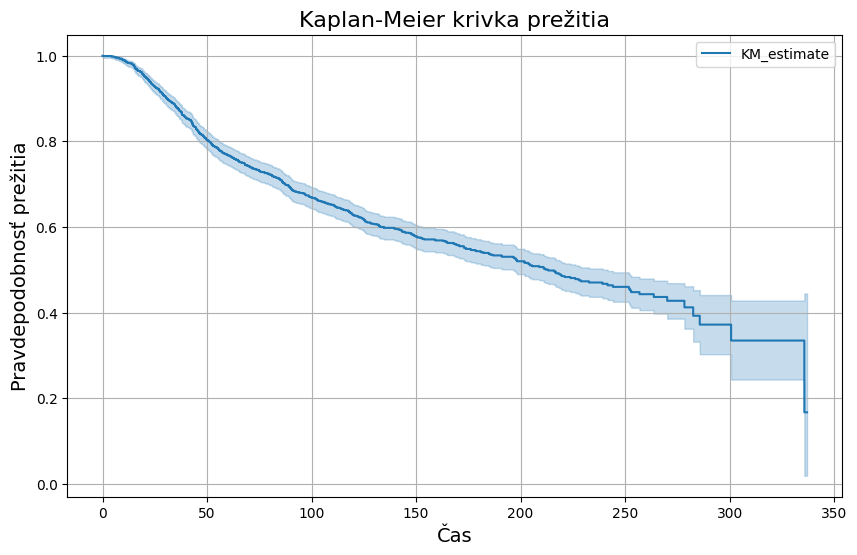

In [82]:
# Vytvorenie objektu KaplanMeierFitter
kmf = KaplanMeierFitter()

# Fitnutie dát (time = čas, event2 = udalosť)
kmf.fit(durations=data['time'], event_observed=data['event'])

# Vykreslenie Kaplan-Meierovej krivky
plt.figure(figsize=(10, 6))
kmf.plot_survival_function(ci_show=True)
plt.title('Kaplan-Meier krivka prežitia', fontsize=16)
plt.xlabel('Čas', fontsize=14)
plt.ylabel('Pravdepodobnosť prežitia', fontsize=14)
plt.grid(True)
plt.show()

In [83]:
relevant_attributes = [
    'event',
    'time',
    "Age at Diagnosis",
    "Type of Breast Surgery",
    "Chemotherapy",
    "ER status measured by IHC",
    "ER Status",
    "Neoplasm Histologic Grade",
    "HER2 Status",
    "Inferred Menopausal State",
    "Lymph nodes examined positive",
    "Nottingham prognostic index",
    "PR Status",
    "Relapse Free Status (Months)",
    "Tumor Size",
    "Tumor Stage",
    "Subtype_Her2",
    "Subtype_LumA",
    "Subtype_LumB",
    "Subtype_claudin-low",
    "Tumor_Subtype_Tubular/ cribriform",
    "HER2_Status_Neutral",
    "IC_2",
    "IC_3",
    "IC_4ER+",
    "IC_5",
    "IC_9",
    "3-GCS_ER+/HER2- Low Prolif",
    "3-GCS_HER2+"
]


In [84]:
relevant_attributes_df = data[relevant_attributes]
cph = CoxPHFitter(alpha=0.05)
cph.fit(relevant_attributes_df, duration_col = 'time', event_col = 'event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -3618.96
         time fit was run = 2025-03-18 15:43:10 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
Age at Diagnosis                   0.04      1.04      0.01            0.02            0.05                1.03                1.05
Type of Breast Surgery             0.17      1.18      0.09           -0.01            0.35                0.99                1.41
Chemotherapy                       0.07      1.08      0.13           -0.19            0.34                0.83                1.40
ER status measured by IHC         -0.33      0.72      0.17           -0.66            0.00                0.51                1.00
ER Status                         -0.03      0.97      0.17           -0.37            0.31                0.69                1.36
Neoplasm Histologic Grade          0.07      1.07      0.11           -0.16            0.29                0.85                1.33
HER2 Status                       -0.25      0.78      0.23           -0.71            0.21                0.49                1.23
Inferred Menopausal State         -0.13      0.87      0.15           -0.43            0.16                0.65                1.17
Lymph nodes examined positive     -0.00      1.00      0.01           -0.03            0.02                0.98                1.02
Nottingham prognostic index        0.18      1.20      0.07            0.05            0.32                1.05                1.37
PR Status                         -0.23      0.79      0.10           -0.42           -0.04                0.65                0.96
Relapse Free Status (Months)      -0.03      0.97      0.00           -0.03           -0.02                0.97                0.98
Tumor Size                         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Tumor Stage                        0.22      1.25      0.09            0.05            0.39                1.06                1.48
Subtype_Her2                       0.10      1.11      0.16           -0.21            0.41                0.81                1.50
Subtype_LumA                      -0.21      0.81      0.16           -0.52            0.10                0.59                1.10
Subtype_LumB                      -0.08      0.93      0.16           -0.39            0.24                0.68                1.27
Subtype_claudin-low                0.21      1.24      0.17           -0.12            0.54                0.89                1.72
Tumor_Subtype_Tubular/ cribriform -0.00      1.00      1.01           -1.99            1.98                0.14                7.26
HER2_Status_Neutral                0.13      1.14      0.12           -0.10            0.36                0.90                1.44
IC_2                               0.02      1.02      0.19           -0.35            0.39                0.70                1.48
IC_3                               0.01      1.01      0.16           -0.31            0.32                0.73                1.38
IC_4ER+                           -0.14      0.87      0.16           -0.44            0.17                0.64                1.18
IC_5                               0.12      1.13      0.23           -0.33            0.57                0.72                1.76
IC_9                               0.34      1.40      0.15            0.05            0.62                1.05                1.86
3-GCS_ER+/HER2- Low Prolif         0.04      1.04      0.13           -0.21 

In [85]:
relevant_attributes1 = [
    'event',
    'time',
    'Age at Diagnosis',
    'Type of Breast Surgery',
    'Chemotherapy',
    'ER status measured by IHC',
    'ER Status',
    'Neoplasm Histologic Grade',
    'HER2 Status',
    'Inferred Menopausal State',
    'Lymph nodes examined positive',
    'Nottingham prognostic index',
    'PR Status',
        'Relapse Free Status (Months)', 


]

In [86]:
relevant_attributes_df = data[relevant_attributes1]

In [87]:
cph = CoxPHFitter(alpha=0.05)
cph.fit(relevant_attributes_df, duration_col = 'time', event_col = 'event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -3632.09
         time fit was run = 2025-03-18 15:43:25 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
Age at Diagnosis               0.04      1.04      0.01            0.03            0.05                1.03                1.05
Type of Breast Surgery         0.23      1.26      0.09            0.06            0.40                1.06                1.49
Chemotherapy                   0.13      1.14      0.13           -0.13            0.38                0.88                1.47
ER status measured by IHC     -0.33      0.72      0.17           -0.66           -0.00                0.52                1.00
ER Status                     -0.20      0.81      0.16           -0.51            0.11                0.60                1.11
Neoplasm Histologic Grade      0.06      1.07      0.11           -0.15            0.27                0.86                1.32
HER2 Status                    0.10      1.10      0.11           -0.11            0.31                0.89                1.37
Inferred Menopausal State     -0.10      0.90      0.15           -0.39            0.18                0.68                1.20
Lymph nodes examined positive -0.00      1.00      0.01           -0.02            0.02                0.98                1.02
Nottingham prognostic index    0.24      1.27      0.06            0.11            0.37                1.12                1.44
PR Status                     -0.24      0.79      0.10           -0.43           -0.05                0.65                0.95
Relapse Free Status (Months)  -0.03      0.97      0.00           -0.03           -0.02                0.97                0.98

                               cmp to      z      p  -log2(p)
covariate                                                    
Age at Diagnosis                 0.00   7.12 <0.005     39.80
Type of Breast Surgery           0.00   2.61   0.01      6.78
Chemotherapy                     0.00   0.99   0.32      1.64
ER status measured by IHC        0.00  -1.99   0.05      4.42
ER Status                        0.00  -1.29   0.20      2.35
Neoplasm Histologic Grade        0.00   0.60   0.55      0.87
HER2 Status                      0.00   0.91   0.36      1.47
Inferred Menopausal State        0.00  -0.71   0.48      1.07
Lymph nodes examined positive    0.00  -0.20   0.84      0.26
Nottingham prognostic index      0.00   3.75 <0.005     12.48
PR Status                        0.00  -2.51   0.01      6.38
Relapse Free Status (Months)     0.00 -28.30 <0.005    582.68
---
Concordance = 0.92
Partial AIC = 7288.17
log-likelihood ratio test = 1492.06 on 12 df
-log2(p) of ll-ratio test = inf

In [88]:
relevant_attributes2 = [
    'event',
    'time',
    'Age at Diagnosis',
    'Type of Breast Surgery',
    'ER status measured by IHC',
    'Nottingham prognostic index',
    'PR Status',
        'Relapse Free Status (Months)', 


]

In [89]:
relevant_attributes_df = data[relevant_attributes2]
cph = CoxPHFitter(alpha=0.05)
cph.fit(relevant_attributes_df, duration_col = 'time', event_col = 'event')
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 1480 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1480
number of events observed = 645
   partial log-likelihood = -3634.39
         time fit was run = 2025-03-18 15:43:30 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
Age at Diagnosis              0.03      1.03      0.00            0.03            0.04                1.03                1.04
Type of Breast Surgery        0.22      1.25      0.09            0.05            0.39                1.05                1.48
ER status measured by IHC    -0.57      0.57      0.11           -0.77           -0.36                0.46                0.70
Nottingham prognostic index   0.27      1.31      0.04            0.20            0.35                1.22                1.41
PR Status                    -0.29      0.75      0.09           -0.46           -0.11                0.63                0.89
Relapse Free Status (Months) -0.03      0.97      0.00           -0.03           -0.02                0.97                0.98

                              cmp to      z      p  -log2(p)
covariate                                                   
Age at Diagnosis                0.00   9.22 <0.005     64.91
Type of Breast Surgery          0.00   2.55   0.01      6.55
ER status measured by IHC       0.00  -5.34 <0.005     23.35
Nottingham prognostic index     0.00   7.22 <0.005     40.84
PR Status                       0.00  -3.24 <0.005      9.72
Relapse Free Status (Months)    0.00 -28.58 <0.005    594.39
---
Concordance = 0.92
Partial AIC = 7280.79
log-likelihood ratio test = 1487.45 on 6 df
-log2(p) of ll-ratio test = inf

### Vizualizacie pomocou Kaplan-Meierovych kriviek

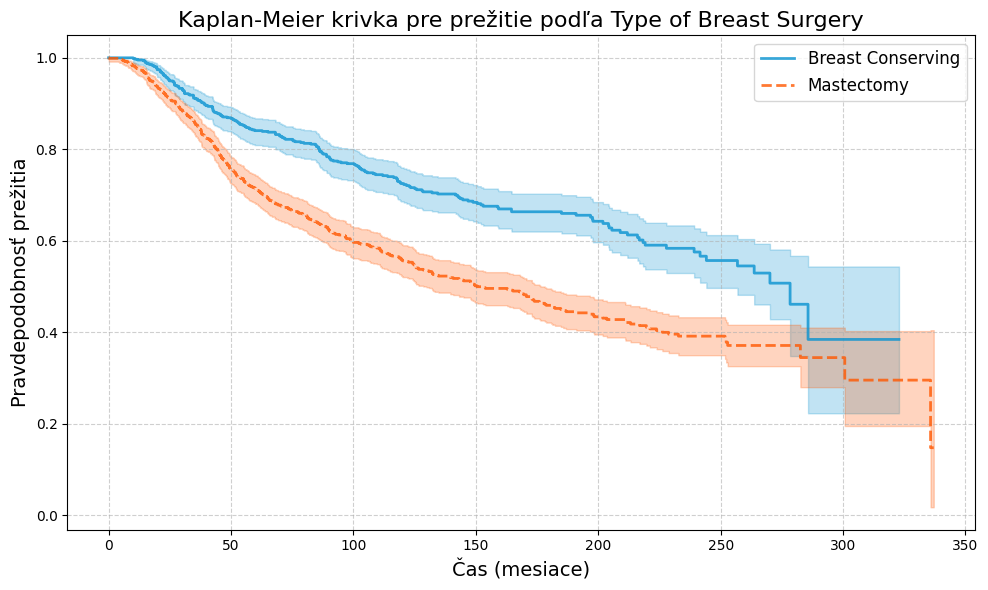

In [97]:
# Definovanie skupín podľa Type of Breast Surgery (zakódované ako 0 = Breast Conserving, 1 = Mastectomy)
bc_group = data[data['Type of Breast Surgery'] == 0]  # Breast Conserving
m_group = data[data['Type of Breast Surgery'] == 1]  # Mastectomy

# Vytvorenie Kaplan-Meier modelu pre každú skupinu
kmf_bc = KaplanMeierFitter()
kmf_m = KaplanMeierFitter()

# Fit pre Breast Conserving a Mastectomy s intervalmi spoľahlivosti
kmf_bc.fit(bc_group['time'], event_observed=bc_group['event'], label="Breast Conserving", alpha=0.05)
kmf_m.fit(m_group['time'], event_observed=m_group['event'], label="Mastectomy", alpha=0.05)

# Vylepšenie grafu
plt.figure(figsize=(10, 6))

# Zobrazenie Kaplan-Meierových kriviek s požadovanými sýtejšími farbami
kmf_bc.plot(ci_show=True, color="#0892D0", linewidth=2, linestyle='-', label="Breast Conserving", alpha=0.8)
kmf_m.plot(ci_show=True, color="#FF5700", linewidth=2, linestyle='--', label="Mastectomy", alpha=0.8)

# Pridanie názvu a popisov osí
plt.title('Kaplan-Meier krivka pre prežitie podľa Type of Breast Surgery', fontsize=16)
plt.xlabel('Čas (mesiace)', fontsize=14)
plt.ylabel('Pravdepodobnosť prežitia', fontsize=14)

# Nastavenie veľkosti a umiestnenia legendy
plt.legend(loc='best', fontsize=12)

# Zlepšenie vzhľadu grafu
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Zobrazenie grafu
plt.show()

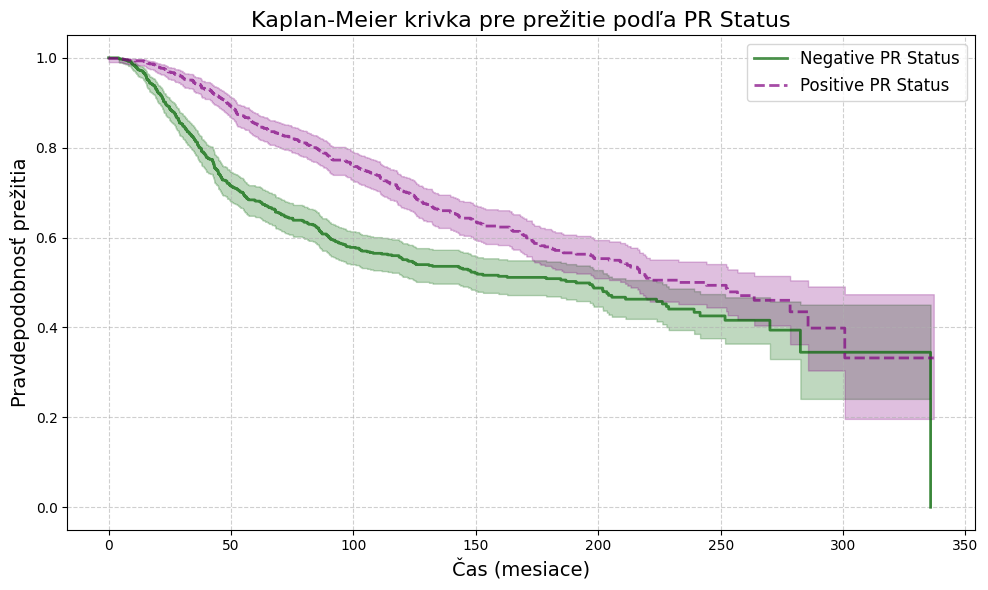

In [95]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Definovanie skupín podľa PR Status
negative_group = data[data['PR Status'] == 0]  # PR Status 0 (negative)
positive_group = data[data['PR Status'] == 1]  # PR Status 1 (positive)

# Vytvorenie Kaplan-Meier modelu pre každú skupinu
kmf_negative = KaplanMeierFitter()
kmf_positive = KaplanMeierFitter()

# Fit pre PR Status (0 - negative) a (1 - positive) s intervalmi spoľahlivosti
kmf_negative.fit(negative_group['time'], event_observed=negative_group['event'], label="Negative PR Status", alpha=0.05)
kmf_positive.fit(positive_group['time'], event_observed=positive_group['event'], label="Positive PR Status", alpha=0.05)

# Vylepšenie grafu
plt.figure(figsize=(10, 6))

# Zobrazenie Kaplan-Meierových kriviek s vylepšeným vzhľadom a intervalmi spoľahlivosti
kmf_negative.plot(ci_show=True, color="darkgreen", linewidth=2, linestyle='-', label="Negative PR Status", alpha=0.7)
kmf_positive.plot(ci_show=True, color="purple", linewidth=2, linestyle='--', label="Positive PR Status", alpha=0.7)

# Pridanie názvu a popisov osí
plt.title('Kaplan-Meier krivka pre prežitie podľa PR Status', fontsize=16)
plt.xlabel('Čas (mesiace)', fontsize=14)
plt.ylabel('Pravdepodobnosť prežitia', fontsize=14)

# Nastavenie veľkosti a umiestnenia legendy
plt.legend(loc='best', fontsize=12)

# Zlepšenie vzhľadu grafu
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Zobrazenie grafu
plt.show()
